ejercicio 1:
recortare el punto de interes de la imagenP.jpg tal cual se muestra en la figura, guardar la imagen recortada en tu disco local, y muestra la imagen original  y la recortada con axis (imagen a colores)  
 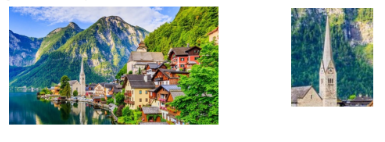

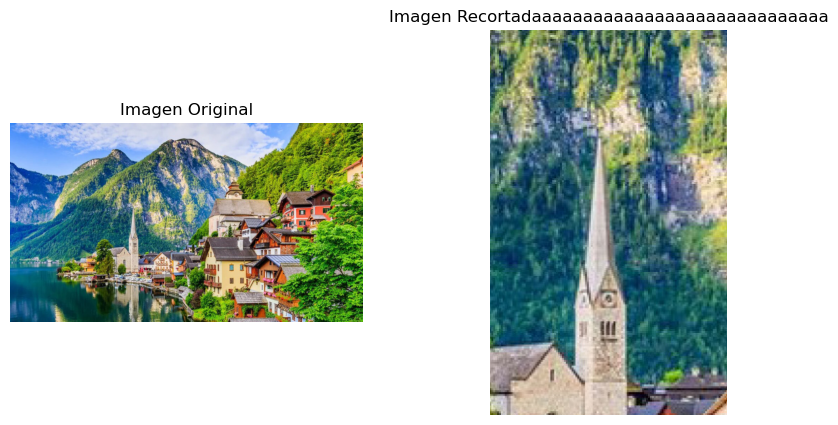

In [155]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

os.makedirs('imagenesGuardadas', exist_ok=True)

imagen = cv2.imread('imagenP.jpg')
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)


fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(imagen_rgb)
axs[0].set_title('Imagen Original')
axs[0].axis('off')

axs[1].imshow(imagen_rgb[355:745, 560:800])
axs[1].set_title('Imagen Recortadaaaaaaaaaaaaaaaaaaaaaaaaaaaaa')
axs[1].axis('off')
plt.savefig('imagenesGuardadas/recortesss.png')
plt.show()


ejercicio 2: generar un degradado lineal a colores(debe coincidir los mismos colores)

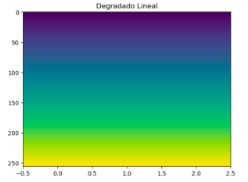

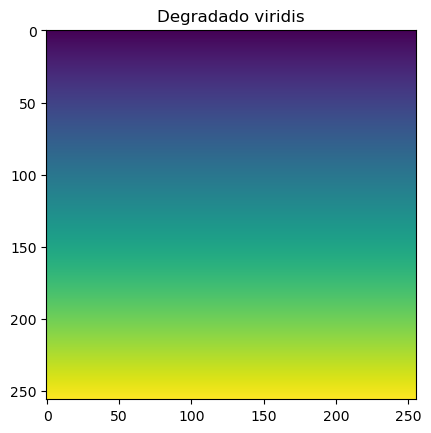

In [151]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('imagenesGuardadas', exist_ok=True)


degradado = np.zeros((256, 256))

for i in range(256):
    degradado[i, :] = i / 255.0

plt.imshow(degradado, cmap='viridis')
plt.title('Degradado viridis')
plt.savefig('imagenesGuardadas/degradado.png')
plt.show()


ejercicio 3: generar una imagen semejante a un tablero de ajedrez tomando en cuenta que cada casilla debe medir 100x100px

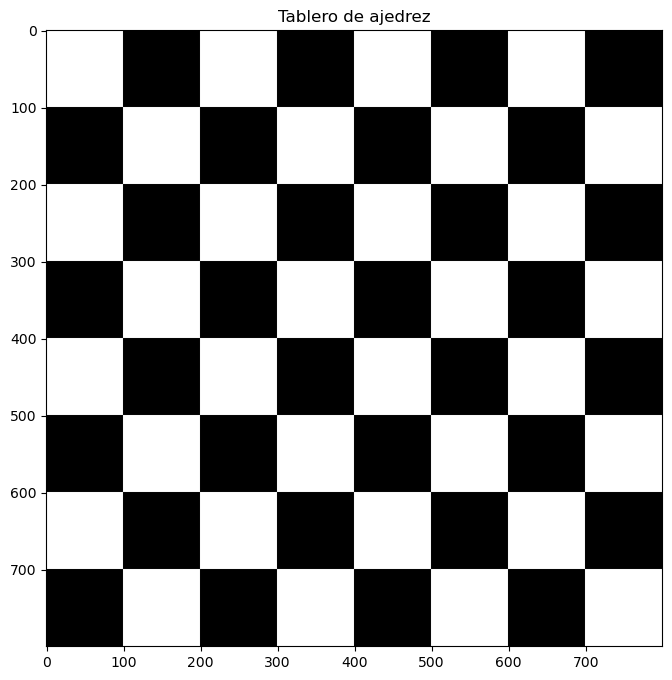

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('imagenesGuardadas', exist_ok=True)


size = 800
half = 100



R1 = np.ones((half, half)) * 255
G1 = np.ones((half, half)) * 255
B1 = np.ones((half, half)) * 255
bloq1 = np.dstack((R1, G1, B1))


R2 = np.ones((half, half)) * 0
G2 = np.ones((half, half)) * 0
B2 = np.ones((half, half)) * 0
bloq2 = np.dstack((R2, G2, B2))


R3 = np.ones((half, half)) * 255
G3 = np.ones((half, half)) * 255
B3 = np.ones((half, half)) * 255
bloq3 = np.dstack((R3, G3, B3))


R4 = np.ones((half, half)) * 0
G4 = np.ones((half, half)) * 0
B4 = np.ones((half, half)) * 0
bloq4 = np.dstack((R4, G4, B4))


R5 = np.ones((half, half)) * 255
G5 = np.ones((half, half)) * 255
B5 = np.ones((half, half)) * 255
bloq5 = np.dstack((R5, G5, B5))


R6 = np.ones((half, half)) * 0
G6 = np.ones((half, half)) * 0
B6 = np.ones((half, half)) * 0
bloq6 = np.dstack((R6, G6, B6))


R7 = np.ones((half, half)) * 255
G7 = np.ones((half, half)) * 255
B7 = np.ones((half, half)) * 255
bloq7 = np.dstack((R7, G7, B7))


R8 = np.ones((half, half)) * 0
G8 = np.ones((half, half)) * 0
B8 = np.ones((half, half)) * 0
bloq8 = np.dstack((R8, G8, B8))



bloques = [b.astype(np.uint8) for b in (bloq1, bloq2, bloq3, bloq4, bloq5, bloq6, bloq7, bloq8)]

img = np.zeros((size, size, 3), dtype=np.uint8)

for row in range(8):
    for col in range(8):
        idx = (row + col) % 8
        y0 = row * half
        x0 = col * half
        img[y0:y0+half, x0:x0+half] = bloques[idx]


cv2.imwrite('imagenesGuardadas/cuadrantes_rgb.png', cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title('Tablero de ajedrez')
plt.savefig('imagenesGuardadas/tablero.png')
plt.show()

ejercicio 4: 

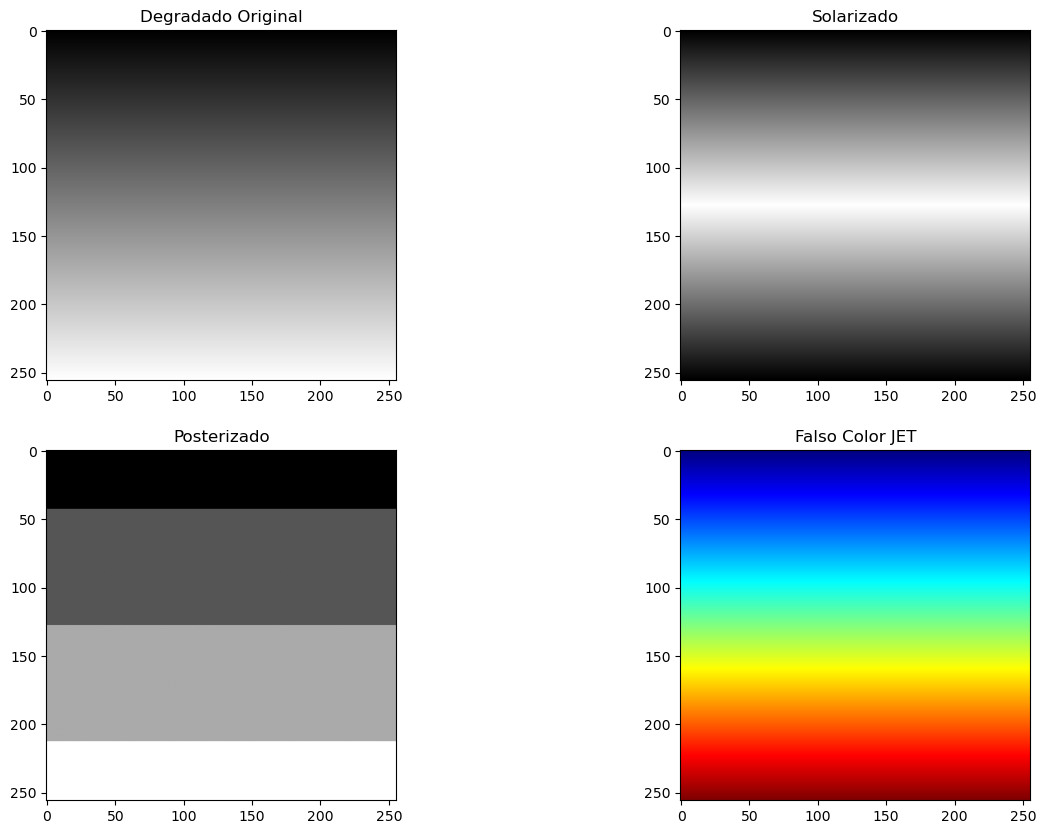

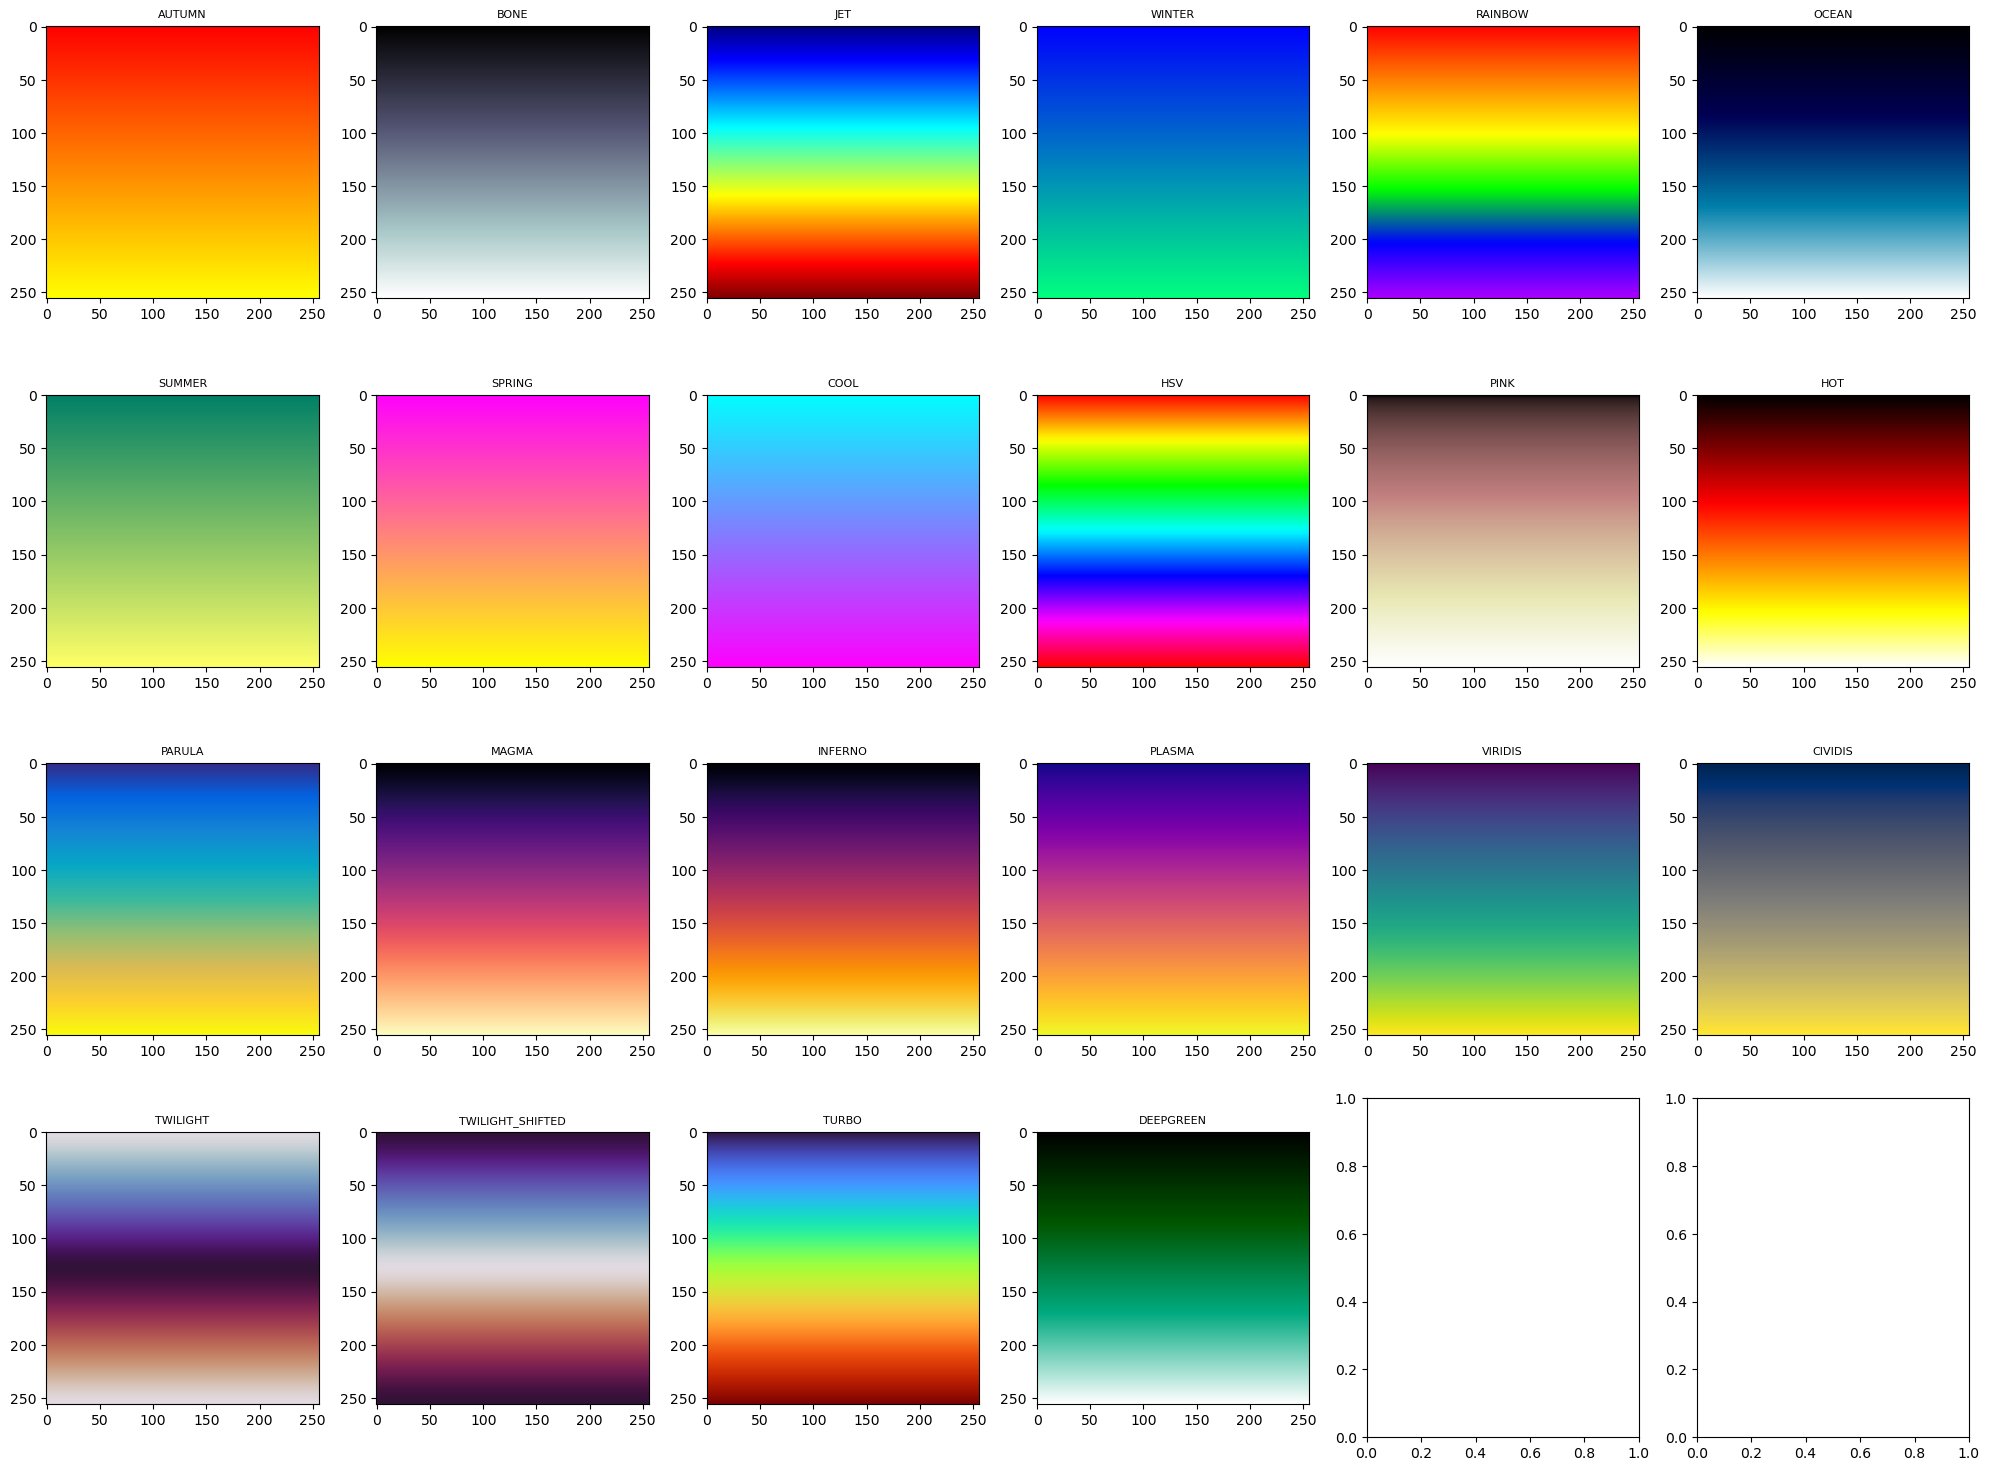

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('imagenesGuardadas', exist_ok=True)


degradado = np.zeros((256, 256), dtype=np.uint8)
for i in range(256):
    degradado[i, :] = i


def solarizar(imagen, umbral):
    img_sol = np.where(imagen < umbral, imagen, 255 - imagen)
    return img_sol.astype(np.uint8)


def posterizar(imagen, niveles):
    factor_escala = 255 / niveles
    img_pos = np.round(imagen / factor_escala) * factor_escala
    return img_pos.astype(np.uint8)


def falso_color(img_gray, colormap=cv2.COLORMAP_JET):
    escal_img = cv2.normalize(img_gray, None, 0, 255, cv2.NORM_MINMAX)
    falso_img = cv2.applyColorMap(escal_img, colormap)
    return falso_img


umbral = 127
img_sol = solarizar(degradado, umbral)
cv2.imwrite('imagenesGuardadas/degradado_solarizado.png', img_sol)


nvl = 3
img_pos = posterizar(degradado, nvl)
cv2.imwrite('imagenesGuardadas/degradado_posterizado.png', img_pos)


colormaps = [
    cv2.COLORMAP_AUTUMN, cv2.COLORMAP_BONE, cv2.COLORMAP_JET, cv2.COLORMAP_WINTER,
    cv2.COLORMAP_RAINBOW, cv2.COLORMAP_OCEAN, cv2.COLORMAP_SUMMER, cv2.COLORMAP_SPRING,
    cv2.COLORMAP_COOL, cv2.COLORMAP_HSV, cv2.COLORMAP_PINK, cv2.COLORMAP_HOT,
    cv2.COLORMAP_PARULA, cv2.COLORMAP_MAGMA, cv2.COLORMAP_INFERNO, cv2.COLORMAP_PLASMA,
    cv2.COLORMAP_VIRIDIS, cv2.COLORMAP_CIVIDIS, cv2.COLORMAP_TWILIGHT, cv2.COLORMAP_TWILIGHT_SHIFTED,
    cv2.COLORMAP_TURBO, cv2.COLORMAP_DEEPGREEN
]

colormap_names = [
    'AUTUMN', 'BONE', 'JET', 'WINTER', 'RAINBOW', 'OCEAN', 'SUMMER', 'SPRING',
    'COOL', 'HSV', 'PINK', 'HOT', 'PARULA', 'MAGMA', 'INFERNO', 'PLASMA',
    'VIRIDIS', 'CIVIDIS', 'TWILIGHT', 'TWILIGHT_SHIFTED', 'TURBO', 'DEEPGREEN'
]

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(degradado, cmap='gray')
plt.title('Degradado Original')


plt.subplot(2, 2, 2)
plt.imshow(img_sol, cmap='gray')
plt.title('Solarizado')


plt.subplot(2, 2, 3)
plt.imshow(img_pos, cmap='gray')
plt.title('Posterizado')


plt.subplot(2, 2, 4)
img_falso_jet = falso_color(degradado, cv2.COLORMAP_JET)
plt.imshow(cv2.cvtColor(img_falso_jet, cv2.COLOR_BGR2RGB))
plt.title('Falso Color JET')


plt.savefig('imagenesGuardadas/procesamientos_degradado.png')
plt.show()


fig, axs = plt.subplots(4, 6, figsize=(20, 15))
for i, (cmap, name) in enumerate(zip(colormaps, colormap_names)):
    img_falso = falso_color(degradado, cmap)
    cv2.imwrite(f'imagenesGuardadas/degradado_falso_color_{name}.png', img_falso)
    row = i // 6
    col = i % 6
    axs[row, col].imshow(cv2.cvtColor(img_falso, cv2.COLOR_BGR2RGB))
    axs[row, col].set_title(name, fontsize=8)
    
plt.tight_layout()
plt.savefig('imagenesGuardadas/todas_paletas_falso_color.png')
plt.show()



ejercicio 5:

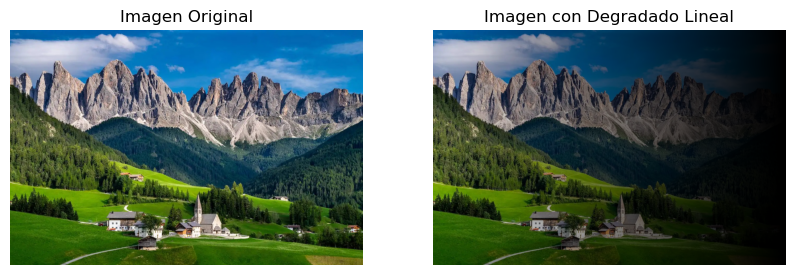

In [165]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('imagenesGuardadas', exist_ok=True)

imagen = cv2.imread('imagen1.jpg')
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
h, w, _ = imagen_rgb.shape
gradient = np.zeros((h, w))
for i in range(w):
    gradient[:, i] = (w - i) / w

imagen_degradada = (imagen_rgb.astype(float) * gradient[:, :, np.newaxis]).astype(np.uint8)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(imagen_rgb)
axs[0].set_title('Imagen Original')
axs[0].axis('off')

axs[1].imshow(imagen_degradada)
axs[1].set_title('Imagen con Degradado Lineal')
axs[1].axis('off')

plt.savefig('imagenesGuardadas/comparacion_imagen1.png')
plt.show()

ejercicio 6:

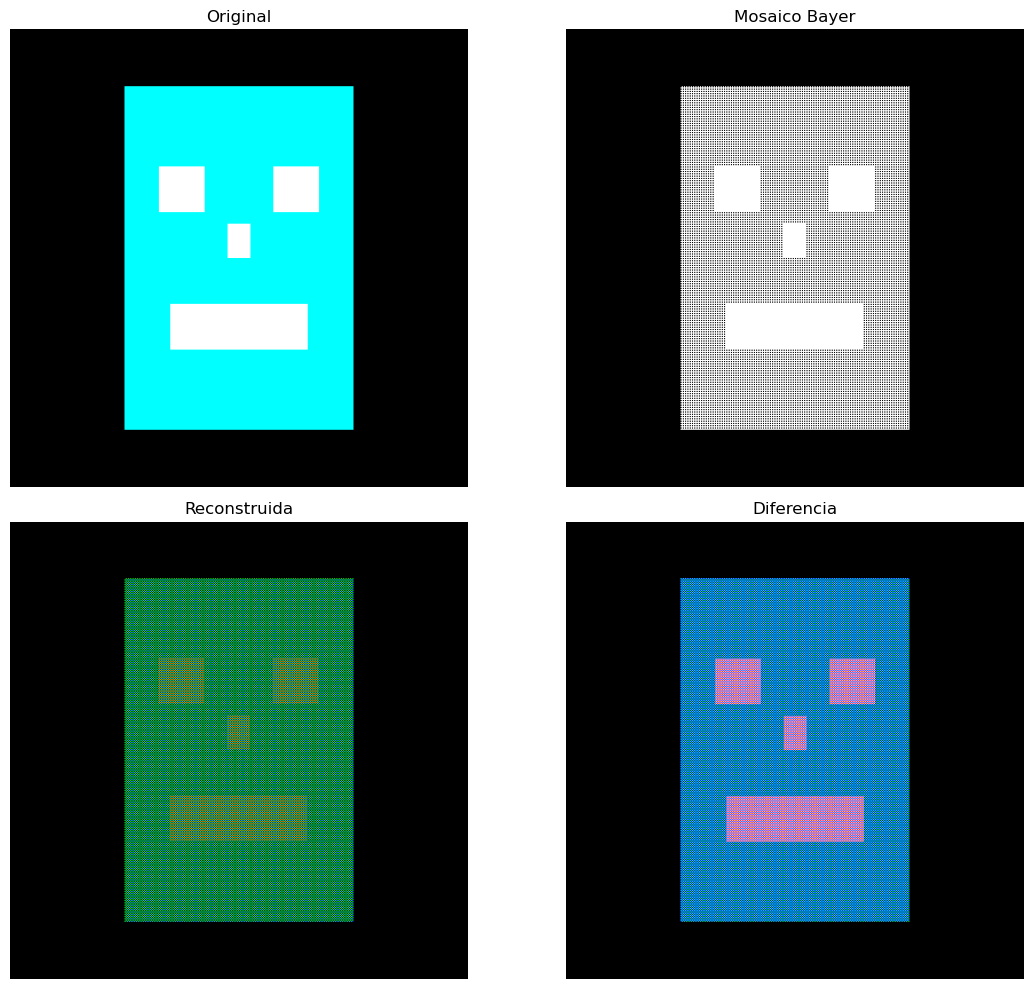

True

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('imagenesGuardadas', exist_ok=True)


img = np.zeros((400, 400, 3), dtype=np.uint8)
img[50:350, 100:300] = [0, 255, 255]  
img[120:160, 130:170] = [255, 255, 255]  
img[120:160, 230:270] = [255, 255, 255] 
img[170:200, 190:210] = [255, 255, 255]  
img[240:280, 140:260] = [255, 255, 255]  

imagen_rgb = img


h, w = imagen_rgb.shape[:2]
bayer = np.zeros((h, w), dtype=np.uint8)
bayer[0::2, 0::2] = imagen_rgb[0::2, 0::2, 0]
bayer[0::2, 1::2] = imagen_rgb[0::2, 1::2, 1]
bayer[1::2, 0::2] = imagen_rgb[1::2, 0::2, 1]
bayer[1::2, 1::2] = imagen_rgb[1::2, 1::2, 2]


resultado = np.zeros((h, w, 3), dtype=np.uint8)
resultado[0::2, 0::2, 0] = bayer[0::2, 0::2]
resultado[0::2, 1::2, 1] = bayer[0::2, 1::2]
resultado[1::2, 0::2, 1] = bayer[1::2, 0::2]
resultado[1::2, 1::2, 2] = bayer[1::2, 1::2]

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs[0, 0].imshow(imagen_rgb)
axs[0, 0].set_title('Original')
axs[0, 0].axis('off')
axs[0, 1].imshow(bayer, cmap='gray')
axs[0, 1].set_title('Mosaico Bayer')
axs[0, 1].axis('off')
axs[1, 0].imshow(resultado)
axs[1, 0].set_title('Reconstruida')
axs[1, 0].axis('off')
axs[1, 1].imshow(cv2.absdiff(resultado, imagen_rgb))
axs[1, 1].set_title('Diferencia')
axs[1, 1].axis('off')

plt.tight_layout()
plt.savefig('imagenesGuardadas/bayer_resultados.png')
plt.show()

cv2.imwrite('imagenesGuardadas/cara_feliz.png', cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('imagenesGuardadas/bayer_reconstruido.png', cv2.cvtColor(resultado, cv2.COLOR_RGB2BGR))